In [70]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

In [3]:
data = pd.read_csv('Spotify-2000.csv')
data.head(5)

,Index,Title,Artist,Top Genre,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Popularity
0,1,Sunrise,Norah Jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71
1,2,Black Night,Deep Purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39
2,3,Clint Eastwood,Gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69
3,4,The Pretender,Foo Fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76
4,5,Waitin' On A Sunny Day,Bruce Springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59


In [58]:
data.drop(['Index'],axis=1)

,Title,Artist,Top Genre,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Popularity
0,Sunrise,Norah Jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71
1,Black Night,Deep Purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39
2,Clint Eastwood,Gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69
3,The Pretender,Foo Fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76
4,Waitin' On A Sunny Day,Bruce Springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,Heartbreak Hotel,Elvis Presley,adult standards,1958,94,21,70,-12,11,72,128,84,7,63
1990,Hound Dog,Elvis Presley,adult standards,1958,175,76,36,-8,76,95,136,73,6,69
1991,Johnny B. Goode,Chuck Berry,blues rock,1959,168,80,53,-9,31,97,162,74,7,74
1992,Take Five,The Dave Brubeck Quartet,bebop,1959,174,26,45,-13,7,60,324,54,4,65


In [73]:
# Converting string into int
for i, value in enumerate(data['Length (Duration)']):
    if not value.isnumeric():
        print(i)
        data.loc[i,'Length (Duration)']=value[0] + value[-3:]
        print('NEW I:',value.isnumeric())
    

In [83]:
print(data.describe())
# Only getting corr for numeric columns
datac = data[['Beats Per Minute (BPM)',	'Energy',	'Danceability', 'Loudness (dB)',	'Liveness',	'Valence','Length (Duration)', 'Acousticness',	'Speechiness',	'Popularity']]
datac.corr()


             Index         Year  Beats Per Minute (BPM)       Energy  \
count  1994.000000  1994.000000             1994.000000  1994.000000   
mean    997.500000  1992.992979              120.215647    59.679539   
std     575.762538    16.116048               28.028096    22.154322   
min       1.000000  1956.000000               37.000000     3.000000   
25%     499.250000  1979.000000               99.000000    42.000000   
50%     997.500000  1993.000000              119.000000    61.000000   
75%    1495.750000  2007.000000              136.000000    78.000000   
max    1994.000000  2019.000000              206.000000   100.000000   

       Danceability  Loudness (dB)     Liveness      Valence  Acousticness  \
count   1994.000000    1994.000000  1994.000000  1994.000000   1994.000000   
mean      53.238215      -9.008526    19.012036    49.408726     28.858074   
std       15.351507       3.647876    16.727378    24.858212     29.011986   
min       10.000000     -27.000000     

,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Popularity
Beats Per Minute (BPM),1.000000,0.156644,-0.140602,0.092927,0.016256,0.059653,0.006252,-0.122472,0.085598,-0.003181
Energy,0.156644,1.000000,0.139616,0.735711,0.174118,0.405175,0.022800,-0.665156,0.205865,0.103393
Danceability,-0.140602,0.139616,1.000000,0.044235,-0.103063,0.514564,-0.135432,-0.135769,0.125229,0.144344
Loudness (dB),0.092927,0.735711,0.044235,1.000000,0.098257,0.147041,-0.056127,-0.451635,0.125090,0.165527
Liveness,0.016256,0.174118,-0.103063,0.098257,1.000000,0.050667,0.032499,-0.046206,0.092594,-0.111978
Valence,0.059653,0.405175,0.514564,0.147041,0.050667,1.000000,-0.203690,-0.239729,0.107102,0.095911
Length (Duration),0.006252,0.022800,-0.135432,-0.056127,0.032499,-0.203690,1.000000,-0.102319,-0.027826,-0.065403
Acousticness,-0.122472,-0.665156,-0.135769,-0.451635,-0.046206,-0.239729,-0.102319,1.000000,-0.098256,-0.087604
Speechiness,0.085598,0.205865,0.125229,0.125090,0.092594,0.107102,-0.027826,-0.098256,1.000000,0.111689
Popularity,-0.003181,0.103393,0.144344,0.165527,-0.111978,0.095911,-0.065403,-0.087604,0.111689,1.000000


In [84]:
from sklearn.preprocessing import MinMaxScaler
for i in data.columns:
    MinMaxScaler(i)

In [85]:
km = KMeans(n_clusters=10)
clusters=km.fit_predict(datac)

In [86]:
data['Music Segment']=clusters
data['Music Segment']=data['Music Segment'].map({1:'cluster 1',2:'cluster 2',3:'cluster 3',4:'cluster 4',5:'cluster 5',6:'cluster 6',7:'cluster 7',
                                                 8:'cluster 8',9:'cluster 9',10:'cluster 10'})

In [87]:
data.head(5)

,Index,Title,Artist,Top Genre,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Popularity,Music Segment
0,1,Sunrise,Norah Jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71,cluster 7
1,2,Black Night,Deep Purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39,NaN
2,3,Clint Eastwood,Gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69,cluster 6
3,4,The Pretender,Foo Fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76,cluster 4
4,5,Waitin' On A Sunny Day,Bruce Springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59,cluster 9


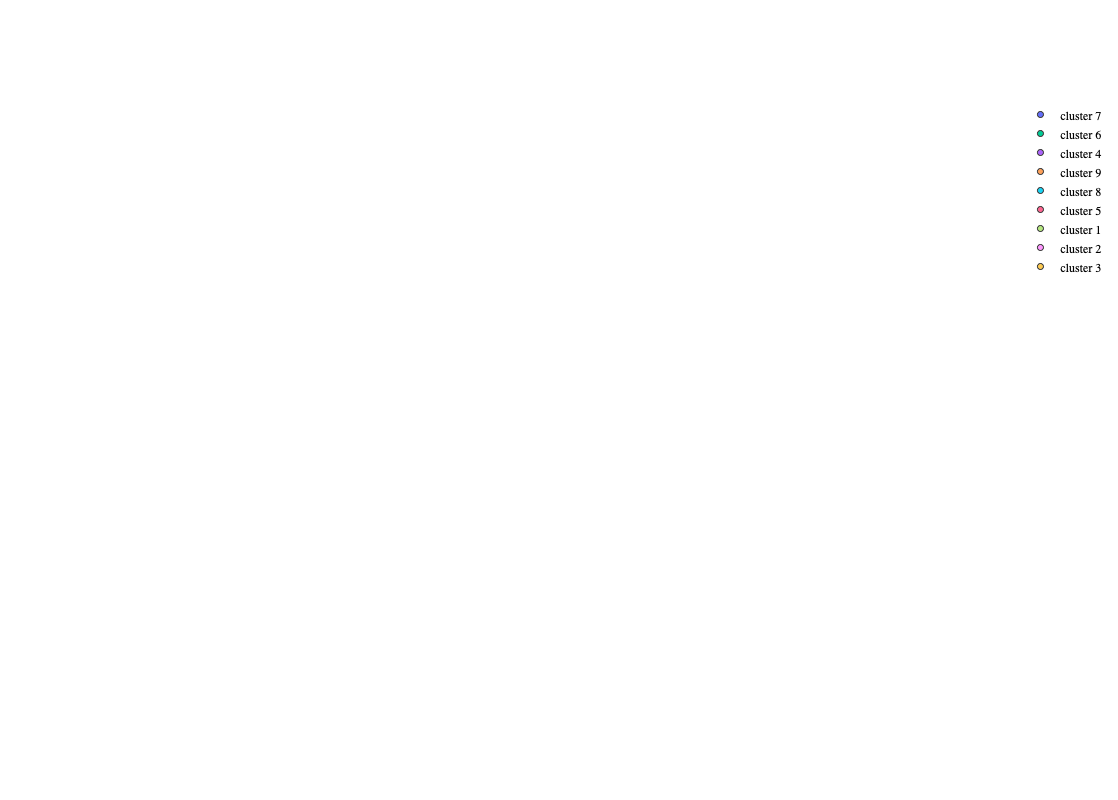

In [92]:
import plotly.graph_objects as go
PLOT = go.Figure()
for i in list(data['Music Segment'].unique()):
    PLOT.add_trace(go.Scatter3d(x = data[data["Music Segment"]== i]['Beats Per Minute (BPM)'],
                                y = data[data["Music Segment"] == i]['Energy'],
                                z = data[data["Music Segment"] == i]['Liveness'],                        
                                mode = 'markers',marker_size = 6, marker_line_width = 1, name = str(i)))

PLOT.update_traces(hovertemplate='Beats Per Minute (BPM): %{x} <br>Energy: %{y} <br>Liveness: %{z}')
    
PLOT.update_layout(width = 800, height = 800, autosize = True, showlegend = True,
                   scene = dict(xaxis=dict(title = 'Beats Per Minute (BPM)', titlefont_color = 'black'),
                                yaxis=dict(title = 'Energy', titlefont_color = 'black'),
                                zaxis=dict(title = 'Liveness', titlefont_color = 'black')), 
                   font = dict(family = "Gilroy", color  = 'black', size = 12))